# CZ and LG (with SCH convex hull) for the P0 two-scenario case — Pyomo + (Gurobi if available)

This notebook reproduces paper-style figures (top row: scenario 1 & 2, bottom: total):

- **CZ** relaxation (constant underestimator per scenario on a fixed interval \(Y=[0,3]\)).
- **LG + SCH** relaxation using the convex hull (biconjugate) \(Q^{**}_{\omega,Y}\) and LG supporting lines.

Implementation notes:
- We use **Pyomo** to compute a **discrete lower convex envelope** (SCH) via an LP with convexity constraints.
- If **Gurobi** is available, we solve with it; otherwise we fall back to any available LP solver.
- The underlying value functions \(v_1, Q_2\) are the cubics from Appendix C (P0-V).


In [43]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import pyomo.environ as pyo

# --------------------------
# Paper-like plot styling
# --------------------------
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 32,
    "axes.linewidth": 1.0,
})

import matplotlib as mpl

mpl.rcParams.update({
    # —— 1) 所有曲线更粗 ——
    "lines.linewidth": 9,          # 默认线宽（你可以试 2.8~4.0）
    "lines.markersize": 7.5,         # marker 大小（如果有点）

    # —— 2) 坐标轴框更粗 ——
    "axes.linewidth": 2.2,           # 坐标轴 spine 的粗细（边框）

    # —— 3) 刻度线更粗更长（“坐标轴更大”的关键观感之一） ——
    "xtick.major.width": 2.0,
    "ytick.major.width": 2.0,
    "xtick.major.size": 7.0,
    "ytick.major.size": 7.0,
    "xtick.minor.width": 1.6,
    "ytick.minor.width": 1.6,
    "xtick.minor.size": 4.0,
    "ytick.minor.size": 4.0,

    # —— 4) 字体（可选，但通常配合加粗更协调） ——
    "axes.labelsize": 22,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,

    # —— 5) legend 线条也跟着变粗（可选） ——
    "legend.fontsize": 32,
    "legend.handlelength": 2.8,      # legend 里小线段长度
    "legend.frameon": True,

    "axes.labelsize": 28,   # 控制 x / Q(x) 这种轴标签大小

})


Y_L, Y_U = 0.0, 3.0

# Grid for convex-envelope LP & plotting (include 2.375 exactly)
h = 0.001
ys = np.arange(Y_L, Y_U + 1e-12, h)   # 0,0.001,...,3.000
N = len(ys)
print("Grid points:", N, " step=", h)

def pick_solver():
    # Prefer Gurobi (user request). Fall back gracefully if unavailable.
    for name in ["gurobi", "gurobi_direct", "gurobi_persistent", "cbc", "glpk", "highs"]:
        try:
            opt = pyo.SolverFactory(name)
            if opt is not None and opt.available(exception_flag=False):
                print("Using solver:", name)
                return opt, name
        except Exception:
            continue
    raise RuntimeError("No LP/MIP solver found. Install Gurobi (recommended) or GLPK/CBC/HiGHS.")

opt, solver_name = pick_solver()

# --- LaTeX rendering for legends (match style with previous notebooks) ---
# Requires a working LaTeX installation (TeX Live/MiKTeX) on your system.
import matplotlib as mpl
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'


Grid points: 3001  step= 0.001
Using solver: gurobi


In [44]:
# --------------------------
# P0 value functions (Appendix C, P0-V)
# --------------------------
def v1(y):
    y = np.asarray(y)
    return 1.00694*y**3 - 4.74589*y**2 + 5.17523*y

def v2(y):
    y = np.asarray(y)
    return -0.677232*y**3 + 3.03949*y**2 - 3.02338*y

def v(y):
    return v1(y) + v2(y)

f1 = v1(ys)
f2 = v2(ys)
fv = f1 + f2

# Exact 1D minimizers on [0,3] (for CZ constants): derivative roots + endpoints
def poly_min_on_interval(coef, a, b):
    dcoef = np.polyder(coef)
    roots = np.roots(dcoef)
    cand = [a, b]
    for r in roots:
        if abs(r.imag) < 1e-10:
            rr = float(r.real)
            if a <= rr <= b:
                cand.append(rr)
    cand = np.array(cand, dtype=float)
    vals = np.polyval(coef, cand)
    i = int(np.argmin(vals))
    return float(cand[i]), float(vals[i])

coef_v1 = np.array([1.00694, -4.74589, 5.17523, 0.0])
coef_v2 = np.array([-0.677232, 3.03949, -3.02338, 0.0])
coef_v  = coef_v1 + coef_v2

y1_star, v1_min = poly_min_on_interval(coef_v1, Y_L, Y_U)
y2_star, v2_min = poly_min_on_interval(coef_v2, Y_L, Y_U)
y_star,  v_min  = poly_min_on_interval(coef_v,  Y_L, Y_U)

print("y1* =", y1_star, "v1(y1*) =", v1_min)
print("y2* =", y2_star, "v2(y2*) =", v2_min)
print("y*  =", y_star,  "v(y*)  =", v_min)


y1* = 2.4399922374158347 v1(y1*) = -0.9999696231981718
y2* = 0.6300007793031237 v2(y2*) = -0.8676956489050687
y*  = 2.619967920966682 v(y*)  = -0.14585646148681


In [45]:
# --------------------------
# CZ relaxation on Y: constant = min_{y in Y} v_omega(y)
# --------------------------
v1_CZ = v1_min
v2_CZ = v2_min
v_CZ  = v1_CZ + v2_CZ

print("CZ constants:")
print("  v1_CZ =", v1_CZ)
print("  v2_CZ =", v2_CZ)
print("  v_CZ  =", v_CZ)


CZ constants:
  v1_CZ = -0.9999696231981718
  v2_CZ = -0.8676956489050687
  v_CZ  = -1.8676652721032405


In [46]:
# --------------------------
# SCH convex hull (lower convex envelope) via Pyomo LP
#   Variables h_i approximating v**(y_i)
#   Constraints:
#       h_i <= f_i   (underestimator)
#       slopes nondecreasing (convexity)
#   Objective:
#       maximize discrete trapezoid integral of h (push as high as possible while convex & <= f)
# --------------------------
def lower_convex_envelope_lp(ygrid, fvals, solver):
    n = len(ygrid)
    m = pyo.ConcreteModel()
    m.I = pyo.RangeSet(0, n-1)
    m.h = pyo.Var(m.I)

    def under_rule(mm, i):
        return mm.h[i] <= float(fvals[i])
    m.under = pyo.Constraint(m.I, rule=under_rule)

    def convex_rule(mm, i):
        if i == 0 or i == n-1:
            return pyo.Constraint.Skip
        dyL = float(ygrid[i] - ygrid[i-1])
        dyR = float(ygrid[i+1] - ygrid[i])
        # (h[i]-h[i-1])/(dyL) <= (h[i+1]-h[i])/(dyR)
        return (mm.h[i] - mm.h[i-1]) * dyR <= (mm.h[i+1] - mm.h[i]) * dyL
    m.convex = pyo.Constraint(m.I, rule=convex_rule)

    w = np.ones(n, dtype=float)
    w[0] = 0.5
    w[-1] = 0.5
    m.obj = pyo.Objective(expr=sum(float(w[i]) * m.h[i] for i in range(n)), sense=pyo.maximize)

    solver.solve(m, tee=False)
    return np.array([pyo.value(m.h[i]) for i in range(n)], dtype=float)

h1 = lower_convex_envelope_lp(ys, f1, opt)
h2 = lower_convex_envelope_lp(ys, f2, opt)
hSCH = h1 + h2

print("Convex envelopes computed (LP).")


Convex envelopes computed (LP).


In [47]:
# --------------------------
# y† = argmin_{y in Y} (h1+h2) on the grid
# --------------------------
idx_dag = int(np.argmin(hSCH))
y_dag = float(ys[idx_dag])
h1_dag = float(h1[idx_dag])
h2_dag = float(h2[idx_dag])
hSCH_dag = float(hSCH[idx_dag])

print("y† =", y_dag)
print("hSCH(y†) =", hSCH_dag)


y† = 2.365
hSCH(y†) = -1.223705536894315


In [48]:
# --------------------------
# LG supporting lines at y† with opposite slopes (LP), maximize slope s
#   line1(y) =  s*y + b1,  line1(y†)=h1(y†)
#   line2(y) = -s*y + b2,  line2(y†)=h2(y†)
# enforce line_omega(y_i) <= h_omega(y_i) for all grid points i.
# --------------------------
m = pyo.ConcreteModel()
m.s = pyo.Var(domain=pyo.Reals)
m.I = pyo.RangeSet(0, N-1)

def c1_rule(mm, i):
    return mm.s*ys[i] + (h1_dag - mm.s*y_dag) <= float(h1[i])
m.c1 = pyo.Constraint(m.I, rule=c1_rule)

def c2_rule(mm, i):
    return -mm.s*ys[i] + (h2_dag + mm.s*y_dag) <= float(h2[i])
m.c2 = pyo.Constraint(m.I, rule=c2_rule)

m.obj = pyo.Objective(expr=m.s, sense=pyo.maximize)
opt.solve(m, tee=False)

s_star = float(pyo.value(m.s))
b1 = h1_dag - s_star*y_dag
b2 = h2_dag + s_star*y_dag

print("LG slope s* =", s_star)
print("b1 =", b1, "b2 =", b2)

def v1_LG(y):
    y = np.asarray(y)
    return s_star*y + b1

def v2_LG(y):
    y = np.asarray(y)
    return -s_star*y + b2

def v_LG(y):
    return v1_LG(y) + v2_LG(y)


LG slope s* = -0.37492868043064304
b1 = -0.09892602978402876 b2 = -1.1247795071102862


In [49]:
# --------------------------
# Plotting (paper-like layout)
# --------------------------
def add_panel_label(ax, label):
    ax.text(0.5, -0.30, label, transform=ax.transAxes, ha="center", va="top", fontsize=13)

def make_figure_CZ(savepath=None):
    fig = plt.figure(figsize=(12.0, 7.2))
    gs = GridSpec(2, 2, height_ratios=[1.0, 1.05], hspace=0.55, wspace=0.65)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[1, 0])

    ax1.plot(ys, f1, color="red", lw=5, label=r"$Q_1$")
    ax1.plot(ys, v1_CZ*np.ones_like(ys), color="red", lw=5, ls=":", label=r"$Q^{\mathrm{CZ}}_{1}$")
    ax1.scatter([y1_star], [v1_CZ], color="black", s=22, zorder=5)
    ax1.text(y1_star-0.15, v1_CZ+0.05, r"$y_1^*$", fontsize=34)
    ax1.set_xlabel(r"$x$")
    ax1.set_ylabel(r"$Q_1(x)$")
    ax1.set_xlim(Y_L, Y_U)
    ax1.set_ylim(-2.0, 2.0)
    ax1.legend(loc="upper right", frameon=True, edgecolor='lightgray', facecolor='white', framealpha=1.0)
    add_panel_label(ax1, r"(a)")

    ax2.plot(ys, f2, color="deepskyblue", lw=5, label=r"$Q_2$")
    ax2.plot(ys, v2_CZ*np.ones_like(ys), color="deepskyblue", lw=5, ls=":", label=r"$Q^{\mathrm{CZ}}_{2}$")
    ax2.scatter([y2_star], [v2_CZ], color="black", s=22, zorder=5)
    ax2.text(y2_star-0.15, v2_CZ+0.05, r"$y_2^*$", fontsize=34)
    ax2.set_xlabel(r"$x$")
    ax2.set_ylabel(r"$Q_2(x)$")
    ax2.set_xlim(Y_L, Y_U)
    ax2.set_ylim(-2.0, 2.0)
    ax2.legend(loc="upper right", frameon=True, edgecolor='lightgray', facecolor='white', framealpha=1.0)
    add_panel_label(ax2, r"(b)")

    #ax3.plot(ys, f1, color="red", lw=5, label=r"$Q_1$")
    #ax3.plot(ys, f2, color="deepskyblue", lw=5, label=r"$Q_2$")
    ax3.plot(ys, fv, color="black", lw=5, label=r"$Q$")
    ax3.plot(ys, v_CZ*np.ones_like(ys), color="black", lw=5, ls=":", label=r"$Q^{\mathrm{CZ}}$")

    #ax3.scatter([y_star], [v_min], color="black", s=26, zorder=6)
    #ax3.text(y_star-0.08, v_min+0.10, r"$y^*$", fontsize=12)
    #ax3.annotate("", xy=(y_star, v_min), xytext=(y_star, v_CZ),
    #             arrowprops=dict(arrowstyle="<->", lw=1.5, color="black"))

    ax3.set_xlabel(r"$x$")
    ax3.set_ylabel(r"$Q_{\,}(x)$")
    ax3.set_xlim(Y_L, Y_U)
    ax3.set_ylim(-2.0, 2.0)
    ax3.legend(loc="upper right", frameon=True, edgecolor='lightgray', facecolor='white', framealpha=1.0)
    add_panel_label(ax3, r"(c)")

    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")
    return fig

def make_figure_LG(savepath=None):
    fig = plt.figure(figsize=(12.0, 7.2))
    gs = GridSpec(2, 2, height_ratios=[1.0, 1.05], hspace=0.55, wspace=0.65)

    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[1, 0])

    ax1.plot(ys, f1, color="red", lw=5, label=r"$Q_1$")
    ax1.plot(ys, v1_LG(ys), color="red", lw=3, ls="--", label=r"$Q^{\mathrm{LG}}_{1}$")
    ax1.plot(ys, h1, color="black", lw=5, ls="-.", label=r"$Q^{**}_{1}$")
    ax1.scatter([y_dag], [h1_dag], color="black", s=24, zorder=6)
    ax1.text(y_dag-0.10, h1_dag+0.10, r"$y^\dagger$", fontsize=34)
    ax1.set_xlabel(r"$x$")
    ax1.set_ylabel(r"$Q_1(x)$")
    ax1.set_xlim(Y_L, Y_U)
    ax1.set_ylim(-2.0, 2.0)
    ax1.legend(loc="upper right", frameon=True, edgecolor='lightgray', facecolor='white', framealpha=1.0)
    add_panel_label(ax1, r"(a)")

    ax2.plot(ys, f2, color="deepskyblue", lw=5, label=r"$Q_2$")
    ax2.plot(ys, v2_LG(ys), color="deepskyblue", lw=5, ls="--", label=r"$Q^{\mathrm{LG}}_{2}$")
    ax2.plot(ys, h2, color="black", lw=5, ls="-.", label=r"$Q^{**}_{2}$")
    ax2.scatter([y_dag], [h2_dag], color="black", s=24, zorder=6)
    ax2.text(y_dag-0.10, h2_dag+0.10, r"$y^\dagger$", fontsize=34)
    ax2.set_xlabel(r"$x$")
    ax2.set_ylabel(r"$Q_2(x)$")
    ax2.set_xlim(Y_L, Y_U)
    ax2.set_ylim(-2.0, 2.0)
    ax2.legend(loc="upper right", frameon=True, edgecolor='lightgray', facecolor='white', framealpha=1.0)
    add_panel_label(ax2, r"(b)")

    #ax3.plot(ys, f1, color="red", lw=5, label=r"$Q_1$")
    #ax3.plot(ys, f2, color="deepskyblue", lw=5, label=r"$Q_2$")
    #ax3.plot(ys, v1_LG(ys), color="red", lw=5, ls="--", label=r"$Q^{\mathrm{LG}}_{1}$")
    #ax3.plot(ys, v2_LG(ys), color="deepskyblue", lw=5, ls="--", label=r"$Q^{\mathrm{LG}}_{2}$")
    ax3.plot(ys, hSCH, color="black", lw=5, ls="-.", label=r"$Q^{\mathrm{LG}}$")
    #ax3.plot(ys, v_LG(ys), color="black", lw=5, ls="--", label=r"$Q^{\mathrm{LG}}$")
    ax3.plot(ys, fv, color="black", lw=5, label=r"$Q$")

#     ax3.scatter([y_dag], [hSCH_dag], color="black", s=26, zorder=6)
#     ax3.text(y_dag-0.08, hSCH_dag+0.10, r"$y^\dagger$", fontsize=12)

    ax3.set_xlabel(r"$x$")
    ax3.set_ylabel(r"$Q_{\,}(x)$")
    ax3.set_xlim(Y_L, Y_U)
    ax3.set_ylim(-2.0, 2.0)
    ax3.legend(loc="upper right", frameon=True, edgecolor='lightgray', facecolor='white', framealpha=1.0)
    add_panel_label(ax3, r"(c)")

    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")
    return fig

# --------------------------
# NEW: Save each panel as its own PNG (so CZ_P0_pyomo / LG_P0_pyomo are NOT 3-in-1)
# --------------------------
def _style_single_panel(ax, xlabel=r"$x$", xlim=None, ylim=None, ylabel=None):
    if ylabel is not None:
        ax.set_ylabel(ylabel)
    ax.set_xlabel(xlabel)
    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.legend(loc="upper right", frameon=True, edgecolor='lightgray', facecolor='white', framealpha=1.0)

def make_CZ_panel_a(savepath=None):
    fig = plt.figure(figsize=(12.0, 7.2))
    ax = fig.add_subplot(111)
    ax.plot(ys, f1, color="red", lw=5, label=r"$Q_1$")
    ax.plot(ys, v1_CZ*np.ones_like(ys), color="red", lw=5, ls=":", label=r"$Q^{\mathrm{CZ}}_{1}$")
    ax.scatter([y1_star], [v1_CZ], color="black", s=22, zorder=5)
    ax.text(y1_star-0.15, v1_CZ+0.05, r"$y_1^*$", fontsize=34)
    _style_single_panel(ax, ylabel=r"$Q_1(x)$", xlim=(Y_L, Y_U), ylim=(-2.0, 2.0))
    add_panel_label(ax, r"(a)")
    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")
    return fig

def make_CZ_panel_b(savepath=None):
    fig = plt.figure(figsize=(12.0, 7.2))
    ax = fig.add_subplot(111)
    ax.plot(ys, f2, color="deepskyblue", lw=5, label=r"$Q_2$")
    ax.plot(ys, v2_CZ*np.ones_like(ys), color="deepskyblue", lw=5, ls=":", label=r"$Q^{\mathrm{CZ}}_{2}$")
    ax.scatter([y2_star], [v2_CZ], color="black", s=22, zorder=5)
    ax.text(y2_star-0.15, v2_CZ+0.05, r"$y_2^*$", fontsize=34)
    _style_single_panel(ax, ylabel=r"$Q_2(x)$", xlim=(Y_L, Y_U), ylim=(-2.0, 2.0))
    add_panel_label(ax, r"(b)")
    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")
    return fig

def make_CZ_panel_c(savepath=None):
    fig = plt.figure(figsize=(12.0, 7.2))
    ax = fig.add_subplot(111)
    ax.plot(ys, fv, color="black", lw=5, label=r"$Q$")
    ax.plot(ys, v_CZ*np.ones_like(ys), color="black", lw=5, ls=":", label=r"$Q^{\mathrm{CZ}}$")
    _style_single_panel(ax, ylabel=r"$Q_{\,}(x)$", xlim=(Y_L, Y_U), ylim=(-2.0, 2.0))
    add_panel_label(ax, r"(c)")
    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")
    return fig

def make_LG_panel_a(savepath=None):
    fig = plt.figure(figsize=(12.0, 7.2))
    ax = fig.add_subplot(111)
    ax.plot(ys, f1, color="red", lw=5, label=r"$Q_1$")
    ax.plot(ys, v1_LG(ys), color="red", lw=5, ls="--", label=r"$Q^{\mathrm{LG}}_{1}$")
    ax.plot(ys, h1, color="black", lw=5, ls="-.", label=r"$Q^{**}_{1}$")
    ax.scatter([y_dag], [h1_dag], color="black", s=24, zorder=6)
    ax.text(y_dag-0.10, h1_dag+0.10, r"$y^\dagger$", fontsize=34)
    _style_single_panel(ax, ylabel=r"$Q_1(x)$", xlim=(Y_L, Y_U), ylim=(-2.0, 2.0))
    add_panel_label(ax, r"(a)")
    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")
    return fig

def make_LG_panel_b(savepath=None):
    fig = plt.figure(figsize=(12.0, 7.2))
    ax = fig.add_subplot(111)
    ax.plot(ys, f2, color="deepskyblue", lw=5, label=r"$Q_2$")
    ax.plot(ys, v2_LG(ys), color="deepskyblue", lw=5, ls="--", label=r"$Q^{\mathrm{LG}}_{2}$")
    ax.plot(ys, h2, color="black", lw=5, ls="-.", label=r"$Q^{**}_{2}$")
    ax.scatter([y_dag], [h2_dag], color="black", s=24, zorder=6)
    ax.text(y_dag-0.10, h2_dag+0.10, r"$y^\dagger$", fontsize=34)
    _style_single_panel(ax, ylabel=r"$Q_2(x)$", xlim=(Y_L, Y_U), ylim=(-2.0, 2.0))
    add_panel_label(ax, r"(b)")
    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")
    return fig

def make_LG_panel_c(savepath=None):
    fig = plt.figure(figsize=(12.0, 7.2))
    ax = fig.add_subplot(111)
    ax.plot(ys, hSCH, color="black", lw=5, ls="-.", label=r"$Q^{\mathrm{LG}}$")
    #ax.plot(ys, v_LG(ys), color="black", lw=5, ls="--", label=r"$Q^{\mathrm{LG}}$")
    ax.plot(ys, fv, color="black", lw=5, label=r"$Q$")
    _style_single_panel(ax, ylabel=r"$Q_{\,}(x)$", xlim=(Y_L, Y_U), ylim=(-2.0, 2.0))
    add_panel_label(ax, r"(c)")
    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")
    return fig


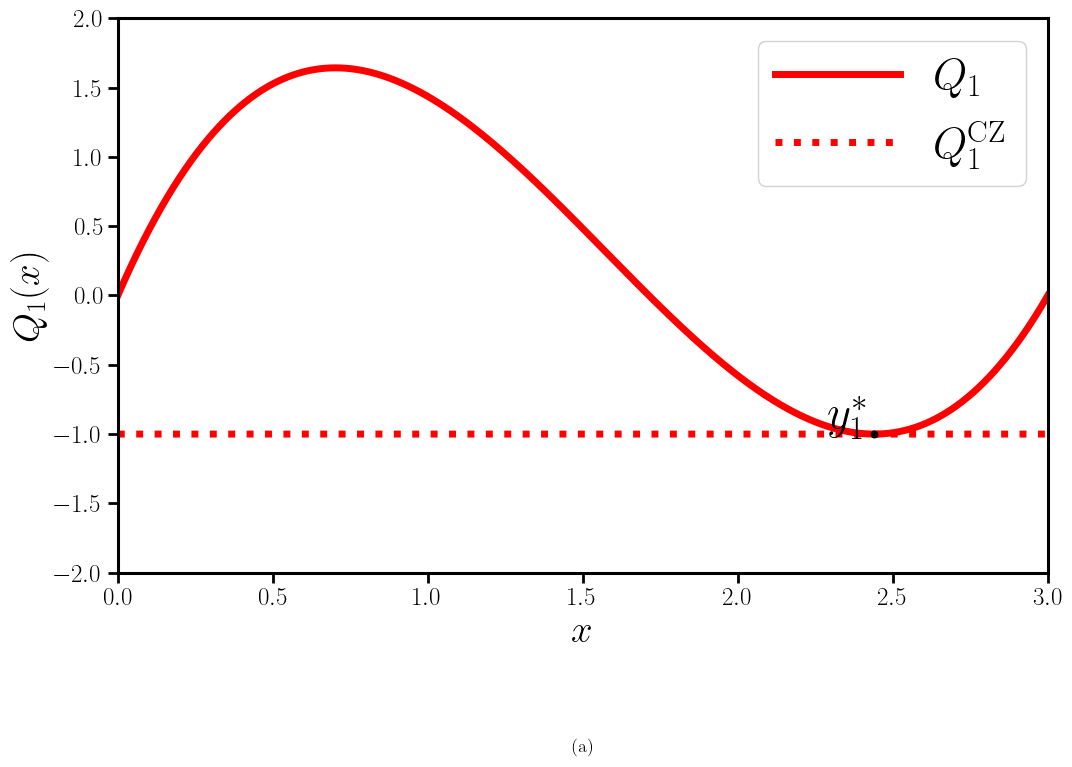

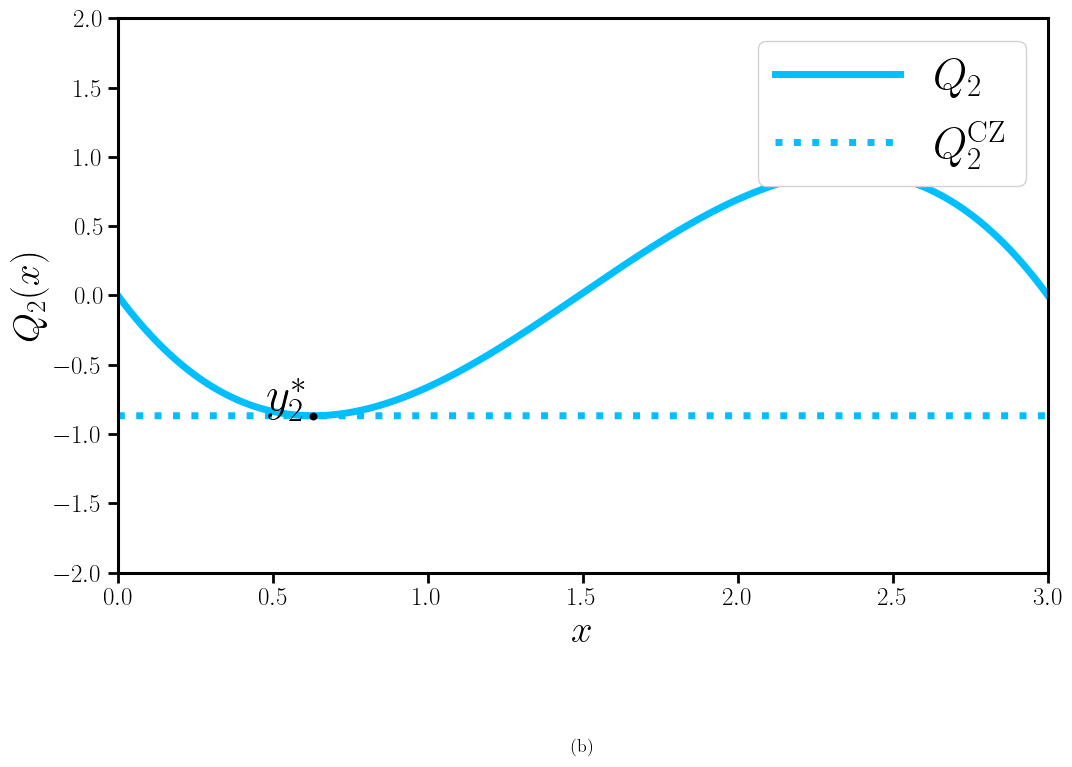

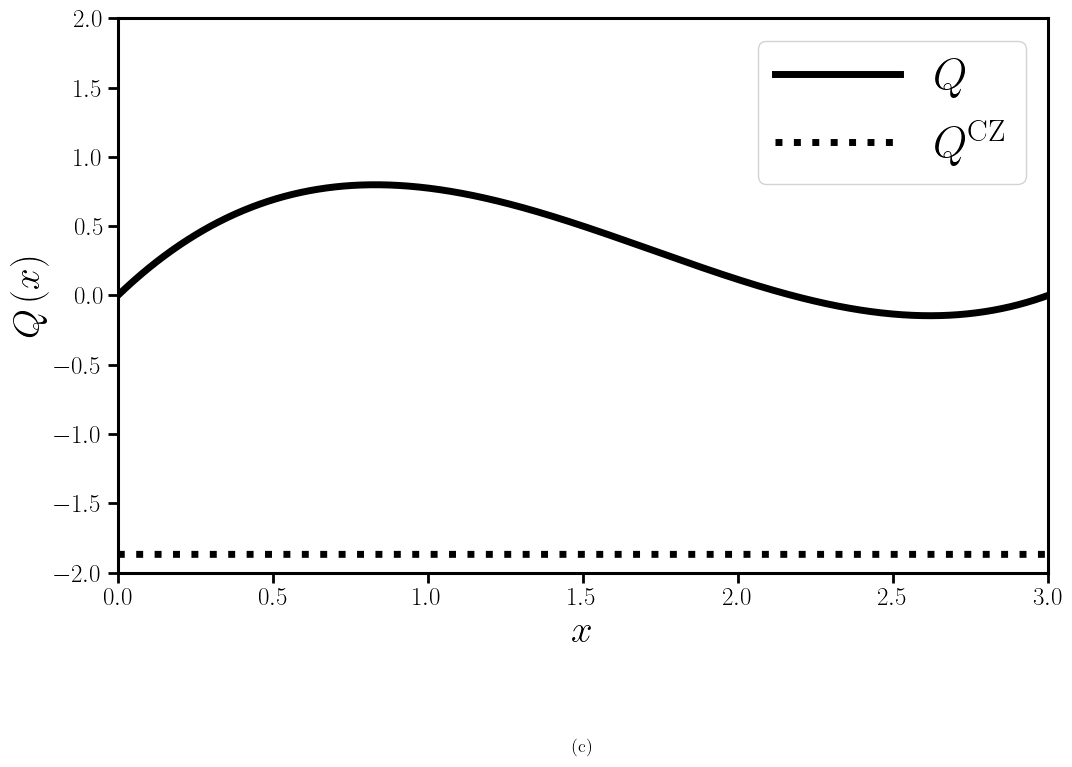

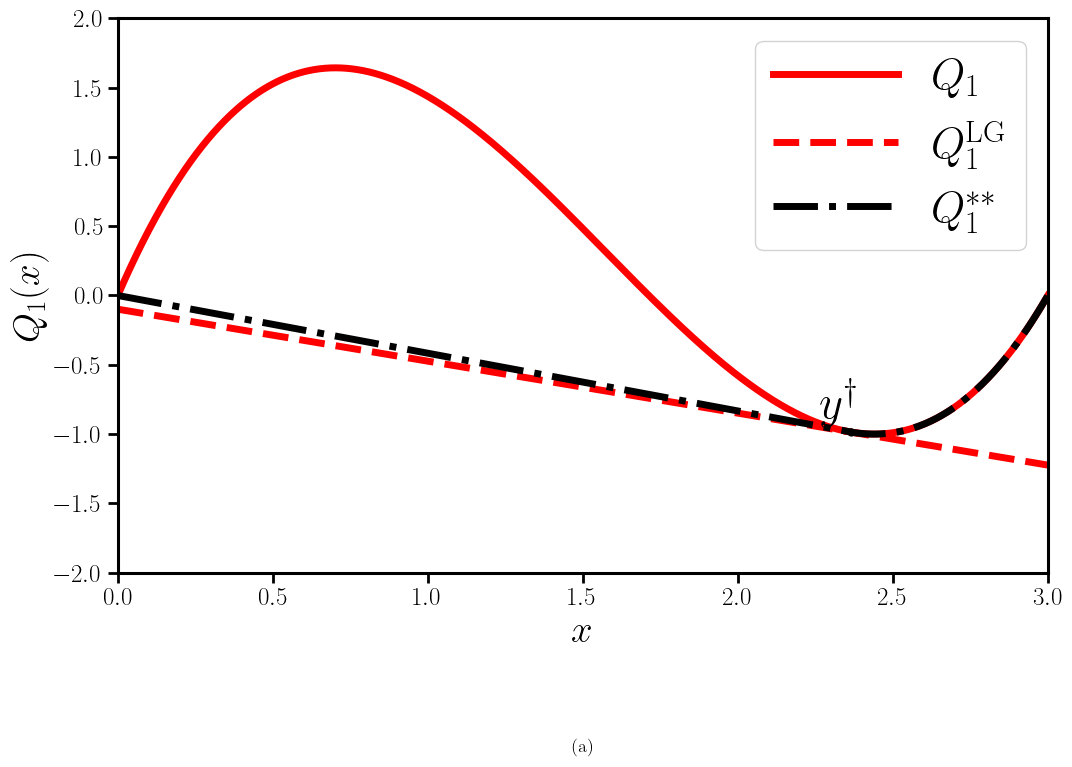

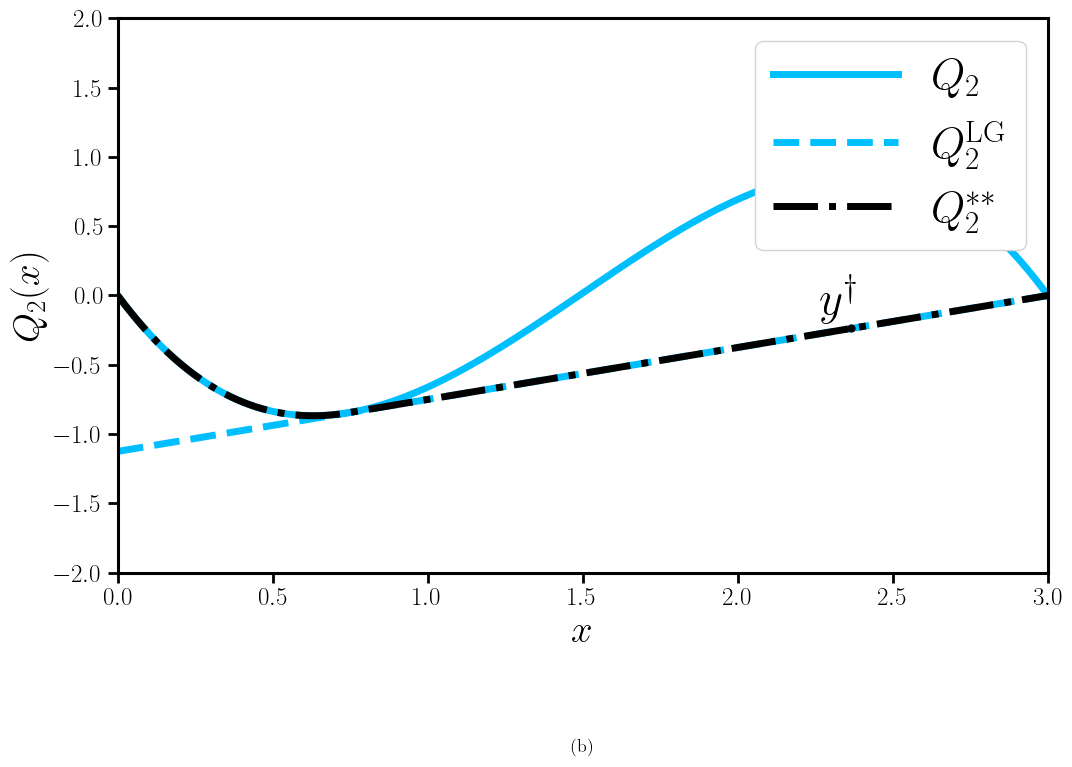

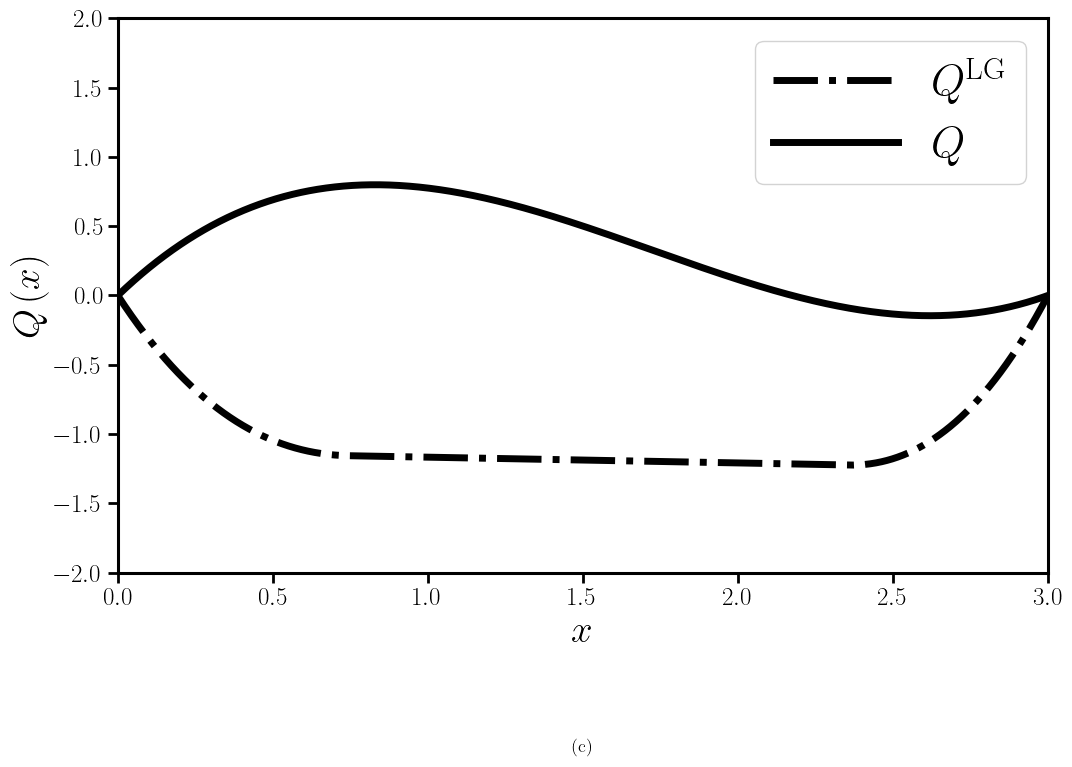

Saved figures:
  CZ_P0_pyomo_1.png
  CZ_P0_pyomo_2.png
  CZ_P0_pyomo_3.png
  LG_P0_pyomo_1.png
  LG_P0_pyomo_2.png
  LG_P0_pyomo_3.png


In [50]:
# --------------------------
# Generate figures (saved as PNG) — one panel per PNG
# --------------------------
fig_cz_1 = make_CZ_panel_a(savepath="CZ_P0_pyomo_1.png")
plt.show()

fig_cz_2 = make_CZ_panel_b(savepath="CZ_P0_pyomo_2.png")
plt.show()

fig_cz_3 = make_CZ_panel_c(savepath="CZ_P0_pyomo_3.png")
plt.show()

fig_lg_1 = make_LG_panel_a(savepath="LG_P0_pyomo_1.png")
plt.show()

fig_lg_2 = make_LG_panel_b(savepath="LG_P0_pyomo_2.png")
plt.show()

fig_lg_3 = make_LG_panel_c(savepath="LG_P0_pyomo_3.png")
plt.show()

print("Saved figures:")
print("  CZ_P0_pyomo_1.png")
print("  CZ_P0_pyomo_2.png")
print("  CZ_P0_pyomo_3.png")
print("  LG_P0_pyomo_1.png")
print("  LG_P0_pyomo_2.png")
print("  LG_P0_pyomo_3.png")



---

# Simplex (piecewise linear) figures



# Simplex (piecewise-linear) method on P0 case — Pyomo + Gurobi (default 5 iterations)

Per scenario \(\omega\):

1. Start with endpoints \(y=0,3\).
2. Build piecewise-linear interpolant \(A^s_\omega\) through current sample points.
3. Compute \(m^s_\omega = \min_{y\in[0,3]}(Q_\omega(y)-A^s_\omega(y))\), then shift \(A^s_\omega+m^s_\omega\).
4. Add an argmin point (grid-based) to the interpolation set (TWO scenarios SHARE the same interpolation points).
5. Repeat for **K=5** iterations.

We compute the min on a dense grid (step \(h=10^{-3}\)). The value \(m^s_\omega\) is obtained via a tiny LP in Pyomo solved by **Gurobi** if available.


In [51]:
import numpy as np
import matplotlib.pyplot as plt
import pyomo.environ as pyo

# --------------------------
# Match plotting style from your CZ/LG notebook
# --------------------------
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 32,
    "axes.linewidth": 1.0,
})

mpl.rcParams.update({
    # —— 1) 所有曲线更粗 ——
    "lines.linewidth": 9,          # 默认线宽（你可以试 2.8~4.0）
    "lines.markersize": 7.5,         # marker 大小（如果有点）

    # —— 2) 坐标轴框更粗 ——
    "axes.linewidth": 2.2,           # 坐标轴 spine 的粗细（边框）

    # —— 3) 刻度线更粗更长（“坐标轴更大”的关键观感之一） ——
    "xtick.major.width": 2.0,
    "ytick.major.width": 2.0,
    "xtick.major.size": 7.0,
    "ytick.major.size": 7.0,
    "xtick.minor.width": 1.6,
    "ytick.minor.width": 1.6,
    "xtick.minor.size": 4.0,
    "ytick.minor.size": 4.0,

    # —— 4) 字体（可选，但通常配合加粗更协调） ——
    "axes.labelsize": 22,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,

    # —— 5) legend 线条也跟着变粗（可选） ——
    "legend.fontsize": 32,
    "legend.handlelength": 2.8,      # legend 里小线段长度
    "legend.frameon": True,

    "axes.labelsize": 28,   # 控制 x / Q(x) 这种轴标签大小

})

FIGSIZE_PANEL = (12.0, 7.2)
FIGSIZE_WIDE  = (12.0, 7.2)



Y_L, Y_U = 0.0, 3.0
h = 0.001
ys = np.arange(Y_L, Y_U + 1e-12, h)
N = len(ys)
print("Grid points:", N, " step=", h)

def pick_solver():
    for name in ["gurobi", "gurobi_direct", "gurobi_persistent", "cbc", "glpk", "highs"]:
        try:
            opt = pyo.SolverFactory(name)
            if opt is not None and opt.available(exception_flag=False):
                print("Using solver:", name)
                return opt, name
        except Exception:
            continue
    raise RuntimeError("No LP/MIP solver found. Install Gurobi (recommended) or GLPK/CBC/HiGHS.")

opt, solver_name = pick_solver()


# --- LaTeX rendering (required for \underline{...} in legends) ---
# NOTE: This requires a working LaTeX installation on your system (e.g., TeX Live/MiKTeX)
# and a supported backend tool (dvipng or similar) that matplotlib uses for usetex.
import matplotlib as mpl
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'


Grid points: 3001  step= 0.001
Using solver: gurobi


In [52]:
# --------------------------
# P0 scenario value functions (Appendix C, P0-V)
# --------------------------
def Q1(y):
    y = np.asarray(y)
    return 1.00694*y**3 - 4.74589*y**2 + 5.17523*y

def Q2(y):
    y = np.asarray(y)
    return -0.677232*y**3 + 3.03949*y**2 - 3.02338*y

def Qtot(y):
    return Q1(y) + Q2(y)

Q1_vals = Q1(ys)
Q2_vals = Q2(ys)
Qtot_vals = Q1_vals + Q2_vals


In [53]:
def piecewise_linear_interp(x_pts, y_pts, x_query):
    # Piecewise-linear interpolant through (x_pts, y_pts), evaluated at x_query. x_pts sorted.
    return np.interp(x_query, x_pts, y_pts)

def compute_ms_via_lp(diff_vals, solver):
    # Compute ms = min_i diff_vals[i] via LP:
    #   maximize ms
    #   s.t. ms <= diff_i  for all i
    m = pyo.ConcreteModel()
    m.ms = pyo.Var(domain=pyo.Reals)
    m.I = pyo.RangeSet(0, len(diff_vals)-1)

    def c_rule(mm, i):
        return mm.ms <= float(diff_vals[i])
    m.c = pyo.Constraint(m.I, rule=c_rule)

    m.obj = pyo.Objective(expr=m.ms, sense=pyo.maximize)
    solver.solve(m, tee=False)
    return float(pyo.value(m.ms))

def simplex_piecewise_underestimator(Q_vals, K=5, y_grid=ys):
    # Per-scenario simplex / piecewise-linear loop on a dense grid.
    x_pts = [float(y_grid[0]), float(y_grid[-1])]  # endpoints 0 and 3
    hist = []

    for k in range(1, K+1):
        x_pts = sorted(set([round(x, 12) for x in x_pts]))
        y_pts = [float(np.interp(x, y_grid, Q_vals)) for x in x_pts]

        As_vals = piecewise_linear_interp(np.array(x_pts), np.array(y_pts), y_grid)
        diff = Q_vals - As_vals  # Q - As

        ms = compute_ms_via_lp(diff, opt)  # equals min on grid
        idx = int(np.argmin(diff))
        y_m = float(y_grid[idx])

        hist.append({"iter": k, "x_pts": x_pts.copy(), "ms": ms, "y_m": y_m, "min_diff": float(diff.min())})

        if all(abs(y_m - x) > 1e-12 for x in x_pts):
            x_pts.append(y_m)

    # final recompute
    x_pts = sorted(set([round(x, 12) for x in x_pts]))
    y_pts = [float(np.interp(x, y_grid, Q_vals)) for x in x_pts]
    As_vals = piecewise_linear_interp(np.array(x_pts), np.array(y_pts), y_grid)
    diff = Q_vals - As_vals
    ms = compute_ms_via_lp(diff, opt)
    As_shift = As_vals + ms
    return x_pts, As_vals, ms, As_shift, hist



def simplex_piecewise_underestimator_shared(Q1_vals, Q2_vals, K=5, y_grid=ys):
    """
    Shared interpolation points across two scenarios.

    Iteration k:
      - Build As1, As2 using SAME x_pts (but different y_pts from Q1/Q2)
      - Compute ms1 = min(Q1 - As1), ms2 = min(Q2 - As2) on y_grid (via LP trick)
      - Let y_m1, y_m2 be argmin points of (Q - As) on the grid
      - Choose next point y_next = y_m_s where |ms_s| is largest (tie -> scenario 1)
      - Add y_next to shared x_pts
    """
    x_pts = [float(y_grid[0]), float(y_grid[-1])]  # endpoints

    hist = []
    for k in range(1, K+1):
        x_pts = sorted(set([round(x, 12) for x in x_pts]))

        # Scenario 1 interpolant on shared x_pts
        y1_pts = [float(np.interp(x, y_grid, Q1_vals)) for x in x_pts]
        As1_vals = piecewise_linear_interp(np.array(x_pts), np.array(y1_pts), y_grid)
        diff1 = Q1_vals - As1_vals
        ms1 = compute_ms_via_lp(diff1, opt)
        y_m1 = float(y_grid[int(np.argmin(diff1))])

        # Scenario 2 interpolant on shared x_pts
        y2_pts = [float(np.interp(x, y_grid, Q2_vals)) for x in x_pts]
        As2_vals = piecewise_linear_interp(np.array(x_pts), np.array(y2_pts), y_grid)
        diff2 = Q2_vals - As2_vals
        ms2 = compute_ms_via_lp(diff2, opt)
        y_m2 = float(y_grid[int(np.argmin(diff2))])

        # Choose next point by max |ms|
        if abs(ms1) >= abs(ms2):
            chosen = 1
            y_next = y_m1
            ms_chosen = ms1
        else:
            chosen = 2
            y_next = y_m2
            ms_chosen = ms2

        hist.append({
            "iter": k,
            "x_pts": x_pts.copy(),
            "ms1": float(ms1), "y_m1": float(y_m1), "min_diff1": float(diff1.min()),
            "ms2": float(ms2), "y_m2": float(y_m2), "min_diff2": float(diff2.min()),
            "chosen": chosen, "y_next": float(y_next), "ms_chosen": float(ms_chosen),
        })

        if all(abs(y_next - x) > 1e-12 for x in x_pts):
            x_pts.append(y_next)

    # final recompute on final shared x_pts
    x_pts = sorted(set([round(x, 12) for x in x_pts]))

    y1_pts = [float(np.interp(x, y_grid, Q1_vals)) for x in x_pts]
    As1_vals = piecewise_linear_interp(np.array(x_pts), np.array(y1_pts), y_grid)
    diff1 = Q1_vals - As1_vals
    ms1 = compute_ms_via_lp(diff1, opt)
    As1_shift = As1_vals + ms1

    y2_pts = [float(np.interp(x, y_grid, Q2_vals)) for x in x_pts]
    As2_vals = piecewise_linear_interp(np.array(x_pts), np.array(y2_pts), y_grid)
    diff2 = Q2_vals - As2_vals
    ms2 = compute_ms_via_lp(diff2, opt)
    As2_shift = As2_vals + ms2

    return x_pts, As1_vals, float(ms1), As1_shift, As2_vals, float(ms2), As2_shift, hist


In [54]:
# --------------------------
# Run (default K=5) — SHARED interpolation points across scenarios
# --------------------------
K = 4

x_shared, As1, ms1, As1_shift, As2, ms2, As2_shift, hist = simplex_piecewise_underestimator_shared(Q1_vals, Q2_vals, K=K)

print("Shared interpolation points:", x_shared)
print("Scenario 1: ms1 =", ms1)
print("Scenario 2: ms2 =", ms2)

sum_shift = As1_shift + As2_shift


# --------------------------
# EXTRA (requested): After reaching max iterations, compute ms again and get the Scenario-1 ms point y
# (Shared points stay fixed; we do NOT add another point.)
# --------------------------
diff1_final = Q1_vals - As1
ms1_final = compute_ms_via_lp(diff1_final, opt)
idx_ms1 = int(np.argmin(diff1_final))
y_ms1_final = float(ys[idx_ms1])

Q1_at_ms = float(Q1_vals[idx_ms1])
As1_at_ms = float(As1[idx_ms1])

print("Post-iter recompute (Scenario 1): ms1_final =", ms1_final, "  y_ms1_final =", y_ms1_final)


Shared interpolation points: [0.0, 0.35, 0.74, 2.44, 2.731, 3.0]
Scenario 1: ms1 = -0.26609351298768136
Scenario 2: ms2 = -0.08223573498595205
Post-iter recompute (Scenario 1): ms1_final = -0.26609351298768136   y_ms1_final = 2.062


In [55]:
# --------------------------
# Plot helpers (match your style)
# Adjust line widths here:
# --------------------------
LW_TRUE  = 5
LW_AS    = 5
LW_SHIFT = 5

def save_or_show(fig, savepath):
    if savepath:
        fig.savefig(savepath, dpi=300, bbox_inches="tight", pad_inches=0.02)
    return fig

def idx_on_grid(x_pts, grid, tol=1e-12):
    """Map each x in x_pts to an index in grid (ys), robust to floating error."""
    grid = np.asarray(grid)
    out = []
    for x in x_pts:
        j = int(np.argmin(np.abs(grid - x)))
        # If mismatch is large, we still proceed (avoids hard failure due to tiny floating diffs)
        out.append(j)
    return np.array(out, dtype=int)

def plot_Q_vs_As(Qvals, Asvals, ylabel, color_Q, color_As, label_Q, label_As,
                 savepath=None, ms_annot=None, sample_x=None, sample_y=None):
    fig = plt.figure(figsize=FIGSIZE_PANEL)
    ax = fig.add_subplot(111)
    ax.plot(ys, Qvals, color=color_Q, lw=LW_TRUE, label=label_Q)
    ax.plot(ys, Asvals, color=color_As, lw=LW_AS, ls="--", label=label_As)
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(ylabel)
    ax.set_xlim(Y_L, Y_U)
    ax.set_ylim(-2.0, 2.0)

    # --- sample points (triangles) ---
    if sample_x is not None:
        if sample_y is None:
            ii = idx_on_grid(sample_x, ys)
            sample_y = np.asarray(Qvals)[ii]
        ax.scatter(
            sample_x, sample_y,
            marker="^",
            s=230,                 # 大一点更显眼
            facecolors="white",    # 白色填充
            edgecolors="black",    # 黑色描边
            linewidths=1.5,        # 描边粗一点
            zorder=10
        )


    # Optional: draw an ms bar/arrow like the reference figure (only when ms_annot is provided)
    # ms_annot should be a dict with keys: y (float), Q (float), A (float), ms (float)
    # --- ms/bar/arrow styling (thicker) ---
    LW_MS_BAR   = 2.0   # bar + caps thickness
    LW_MS_ARROW = 1.5   # arrow thickness
    FS_MS       = 45    # ms label fontsize

    if ms_annot is not None:
        y0 = float(ms_annot["y"])
        q0 = float(ms_annot["Q"])
        a0 = float(ms_annot["A"])
        ms0 = float(ms_annot["ms"])

        # vertical bar with small end caps
        dx = 0.02 * (Y_U - Y_L)
        
        ax.plot([y0, y0], [a0, q0], color="blue", lw=LW_MS_BAR, zorder=5)
        ax.plot([y0 - dx, y0 + dx], [a0, a0], color="blue", lw=LW_MS_BAR, zorder=5)
        ax.plot([y0 - dx, y0 + dx], [q0, q0], color="blue", lw=LW_MS_BAR, zorder=5)

        # arrow + label “-m_s” (distance between Q and A at the ms point)
        ym = 0.5 * (a0 + q0)
        ax.annotate(
            r"$m_s$",
            xy=(y0, ym),
            xytext=(y0 + 0.08 * (Y_U - Y_L), ym),
            color="blue",
            fontsize=FS_MS,
        fontweight="bold",
            va="center",
            arrowprops=dict(arrowstyle="->", color="blue", lw=LW_MS_BAR),
            zorder=6
        )
    ax.legend(loc="upper right", frameon=True)


    return save_or_show(fig, savepath)

def plot_Q_vs_Shift(Qvals, Shiftvals, ylabel, color_Q, color_Shift, label_Q, label_Shift, savepath=None, sample_x=None, sample_y=None):
    fig = plt.figure(figsize=FIGSIZE_PANEL)
    ax = fig.add_subplot(111)
    ax.plot(ys, Qvals, color=color_Q, lw=LW_TRUE, label=label_Q)
    ax.plot(ys, Shiftvals, color=color_Shift, lw=LW_SHIFT, ls="--", label=label_Shift)
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(ylabel)
    ax.set_xlim(Y_L, Y_U)
    ax.set_ylim(-2.0, 2.0)

    # --- sample points (triangles) ---
    if sample_x is not None:
        if sample_y is None:
            ii = idx_on_grid(sample_x, ys)
            sample_y = np.asarray(Qvals)[ii]
            ax.scatter(
                sample_x, sample_y,
                marker="^",
                s=230,                 # 大一点更显眼
                facecolors="white",    # 白色填充
                edgecolors="black",    # 黑色描边
                linewidths=1.5,        # 描边粗一点
                zorder=10
            )

    ax.legend(loc="upper right", frameon=True)


    return save_or_show(fig, savepath)

def plot_total(Qtot, sumShift, savepath=None):
    fig = plt.figure(figsize=FIGSIZE_PANEL)
    ax = fig.add_subplot(111)
    ax.plot(ys, Qtot, color="black", lw=LW_TRUE, label=r"$Q$")
    ax.plot(ys, sumShift, color="black", lw=LW_SHIFT, ls="--",
            label=r"$\underline{Q}_1 + \underline{Q}_2$")
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$Q_{\,}(x)$")
    ax.set_xlim(Y_L, Y_U)
    ax.set_ylim(-2.0, 2.0)
    ax.legend(loc="upper right", frameon=True)


    return save_or_show(fig, savepath)


def plot_total_no_ms(Qtot, sumA, savepath=None):
    fig = plt.figure(figsize=FIGSIZE_PANEL)
    ax = fig.add_subplot(111)
    ax.plot(ys, Qtot, color="black", lw=LW_TRUE, label=r"$Q$")
    ax.plot(ys, sumA, color="black", lw=LW_AS, ls="--",
            label=r"$A_1 + A_2$")
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$Q_{\,}(x)$")
    ax.set_xlim(Y_L, Y_U)
    ax.set_ylim(-2.0, 2.0)
    ax.legend(loc="upper right", frameon=True)
    return save_or_show(fig, savepath)


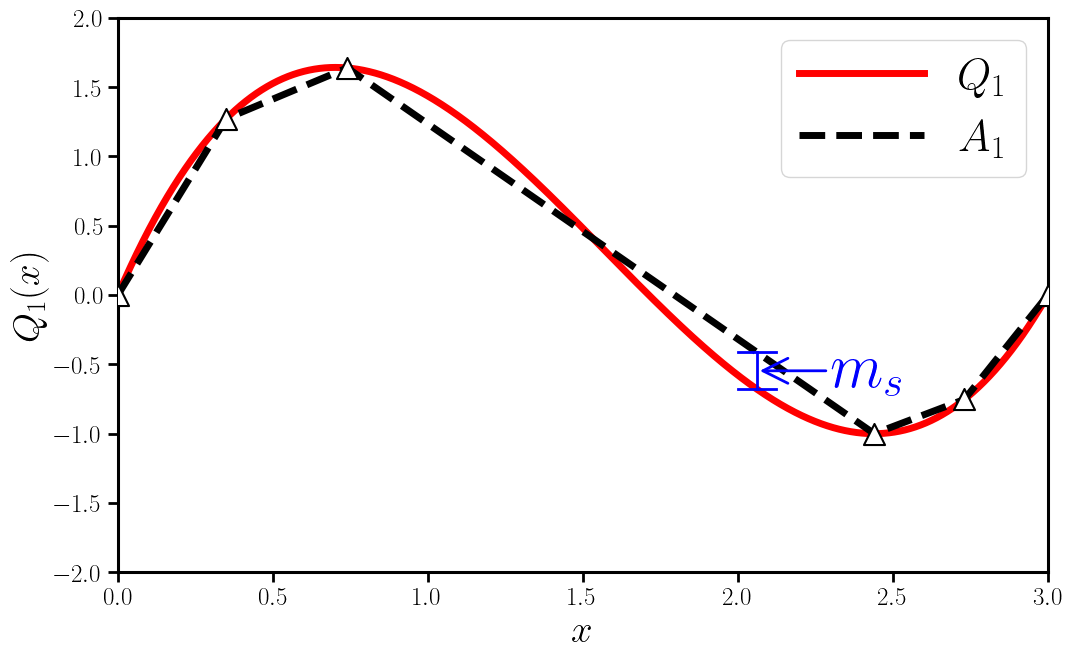

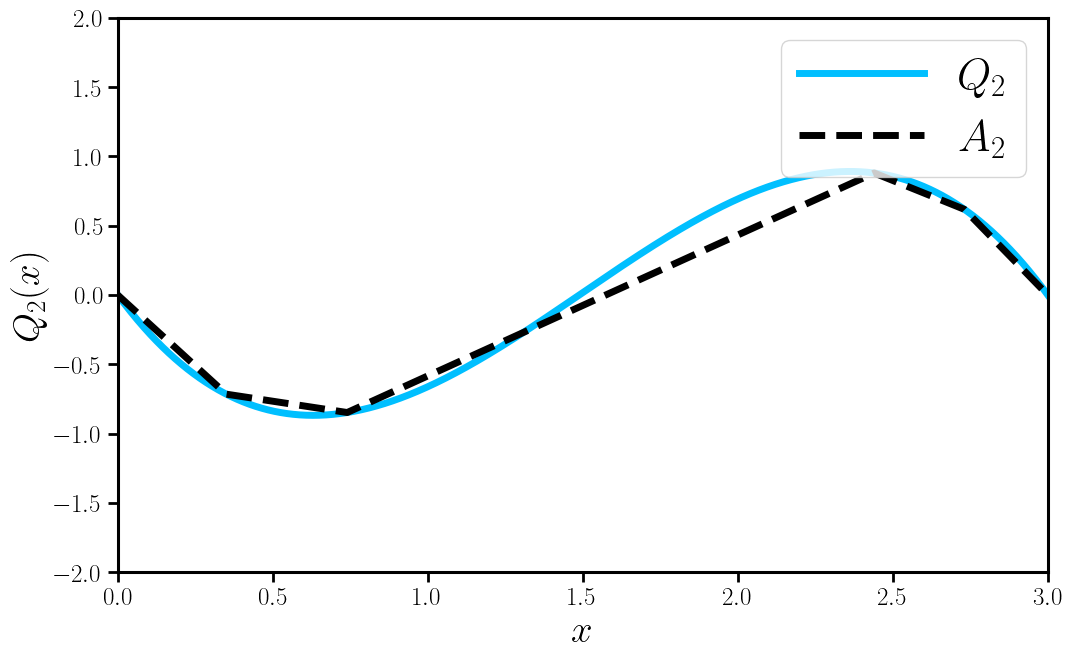

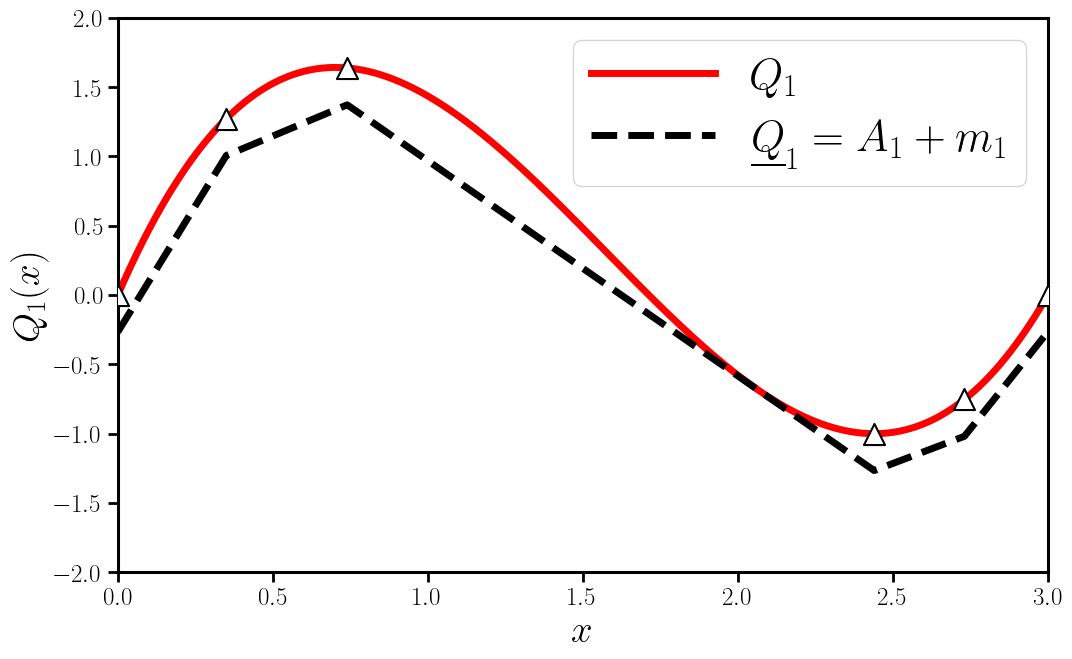

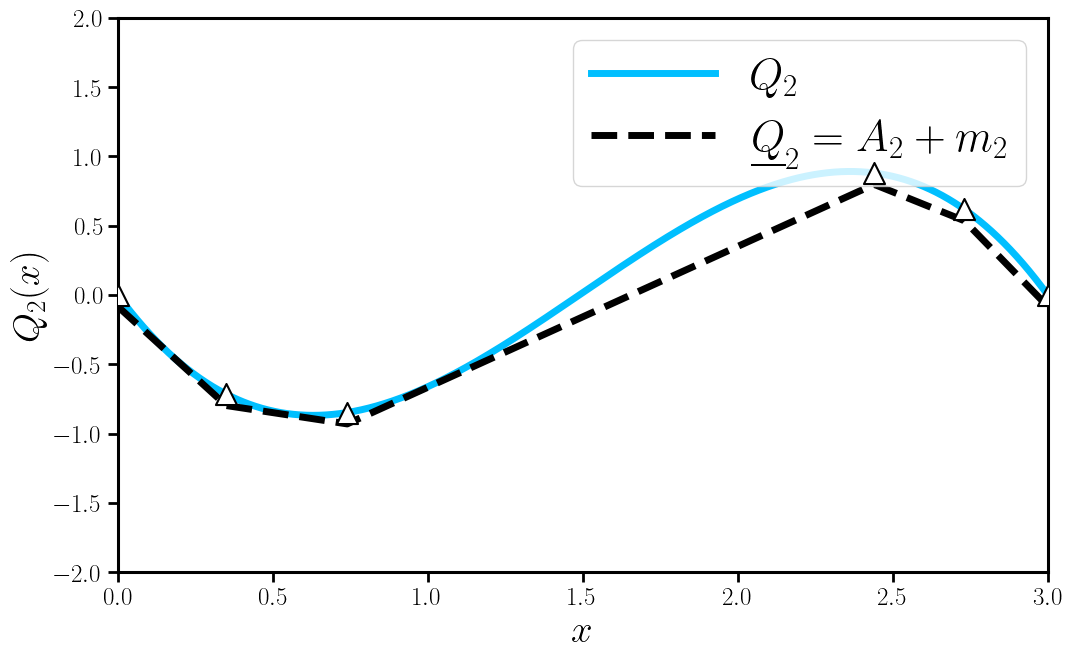

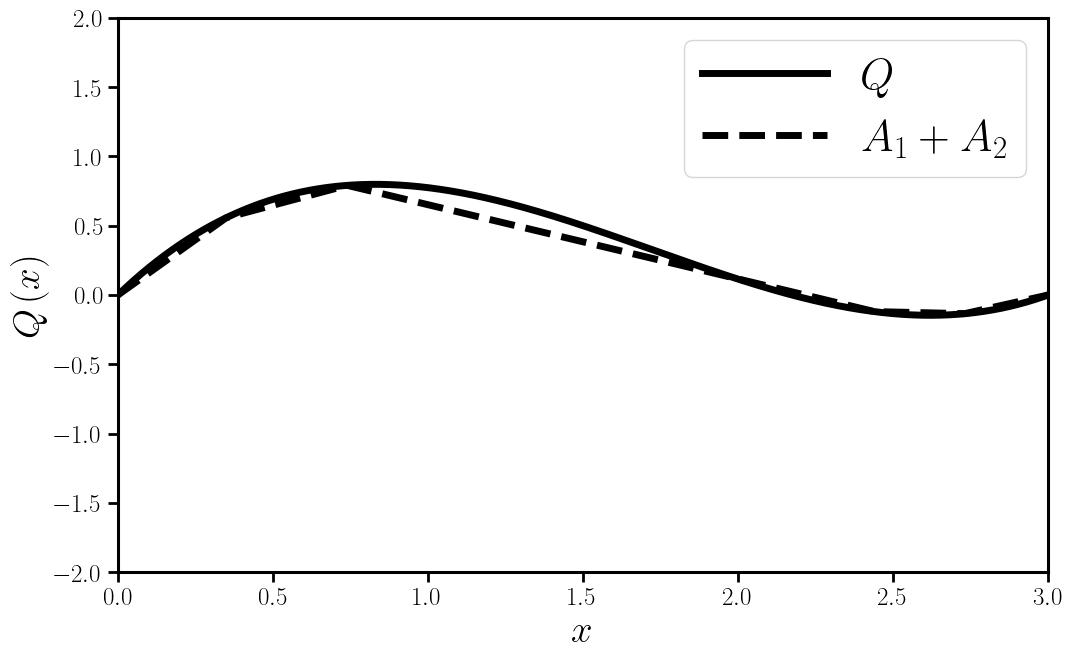

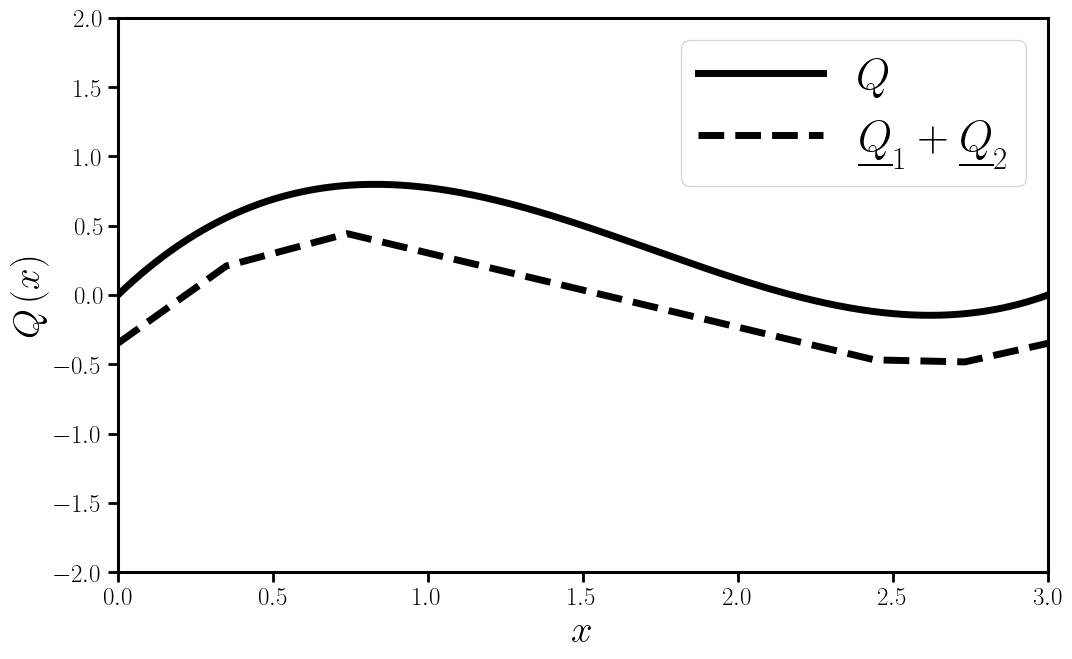

Saved PNGs:
  simplex_fig1_s1_As.png
  simplex_fig2_s2_As.png
  simplex_fig3_s1_As_ms.png
  simplex_fig4_s2_As_ms.png
  simplex_fig5_total_no_ms.png
  simplex_fig6_total.png


In [56]:
# --------------------------
# Output 6 figures (requested + extra no-ms comparison)
# --------------------------

# 1) Scenario 1: As and true
plot_Q_vs_As(
    Q1_vals, As1,
    ylabel=r"$Q_1(x)$",
    color_Q="red", color_As="black",
    label_Q=r"$Q_1$", label_As=r"$A_1$",
    ms_annot={"y": y_ms1_final, "Q": Q1_at_ms, "A": As1_at_ms, "ms": ms1_final},
    sample_x=x_shared,
    savepath="simplex_fig1_s1_As.png"
)
plt.show()

# 2) Scenario 2: As and true
plot_Q_vs_As(
    Q2_vals, As2,
    ylabel=r"$Q_2(x)$",
    color_Q="deepskyblue", color_As="black",
    label_Q=r"$Q_2$", label_As=r"$A_2$",
    savepath="simplex_fig2_s2_As.png"
)
plt.show()

# 3) Scenario 1: As+ms and true
plot_Q_vs_Shift(
    Q1_vals, As1_shift,
    ylabel=r"$Q_1(x)$",
    color_Q="red", color_Shift="black",
    label_Q=r"$Q_1$", label_Shift=r"$\underline{Q}_1=A_1+m_1$",
    sample_x=x_shared,
    savepath="simplex_fig3_s1_As_ms.png"
)
plt.show()

# 4) Scenario 2: As+ms and true
plot_Q_vs_Shift(
    Q2_vals, As2_shift,
    ylabel=r"$Q_2(x)$",
    color_Q="deepskyblue", color_Shift="black",
    label_Q=r"$Q_2$", label_Shift=r"$\underline{Q}_2=A_2+m_2$",
    sample_x=x_shared,
    savepath="simplex_fig4_s2_As_ms.png"
)
plt.show()


# 5) Total (NO ms): true v and (A1 + A2)
plot_total_no_ms(
    Qtot_vals, As1 + As2,
    savepath="simplex_fig5_total_no_ms.png"
)
plt.show()

# 6) Total: true v and sum of (As+ms)
plot_total(
    Qtot_vals, sum_shift,
    savepath="simplex_fig6_total.png"
)
plt.show()

print("Saved PNGs:")
print("  simplex_fig1_s1_As.png")
print("  simplex_fig2_s2_As.png")
print("  simplex_fig3_s1_As_ms.png")
print("  simplex_fig4_s2_As_ms.png")
print("  simplex_fig5_total_no_ms.png")
print("  simplex_fig6_total.png")
